# 第5章 5.3 业务可视化看板展示（Notebook复现）

本 notebook 用于答辩展示 `customer_profile`、`gold_match`、`segmentation`、`realtime_sales` 四类可视化结果。

建议讲解顺序：页面截图 -> 指标结果 -> 一句话结论。

In [1]:
import sys
from pathlib import Path

# 当前 notebook 在 backend/jupyter，向上一层加入 backend 目录
BACKEND_DIR = Path.cwd().resolve().parent
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

import pandas as pd
import matplotlib.pyplot as plt
from db import get_conn
from services.apriori import get_rules_summary

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

print("backend dir:", BACKEND_DIR)

backend dir: C:\Users\user\Downloads\project\backend


In [2]:
def fetch_df(sql, params=None):
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(sql, params or ())
            rows = cur.fetchall()
        return pd.DataFrame(rows)
    finally:
        conn.close()

def table_columns(table_name):
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(f"SHOW COLUMNS FROM `{table_name}`")
            return [row["Field"] for row in cur.fetchall()]
    finally:
        conn.close()

orders_cols = set(table_columns("orders"))
order_items_cols = set(table_columns("order_items"))

print("orders columns:", sorted(orders_cols))
print("order_items columns:", sorted(order_items_cols))

orders columns: ['cancel_reason', 'created_at', 'delivery_mode', 'discount_amount', 'finished_at', 'id', 'order_no', 'paid_amount', 'paid_at', 'payable_amount', 'payment_method', 'status', 'store_id', 'total_amount', 'user_id']
order_items columns: ['id', 'line_total', 'order_id', 'product_id', 'product_name_snap', 'product_variant_id', 'qty', 'unit_price']


## 5.3 可视化看板总览

- 插入截图：`图5-7 系统可视化页面总体展示（Gold Match）`
- 建议截图内容：网络图 + 强规则表 + 套餐建议区块同时出现。

### 5.3.1 用户画像可视化（Customer Profile）

- 插入截图：用户画像页面（可命名为图5-9）
- 说明重点：用户消费频次分布、高活跃用户占比。

         user_id    order_cnt
count  87.000000    87.000000
mean   44.000000  4342.068966
std    25.258662    67.125844
min     1.000000  4160.000000
25%    22.500000  4297.500000
50%    44.000000  4338.000000
75%    65.500000  4386.500000
max    87.000000  4518.000000


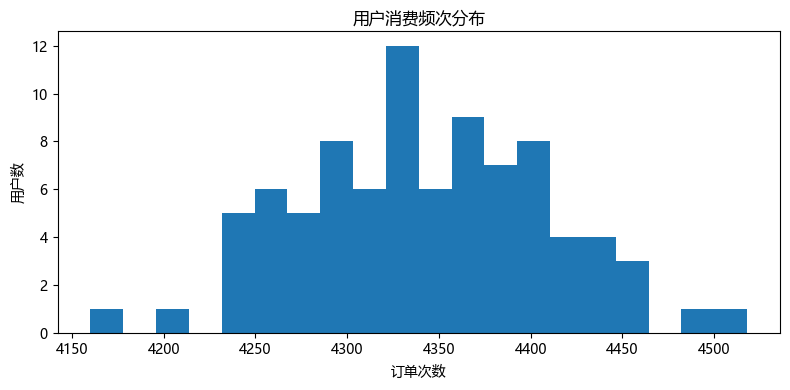

In [3]:
# 目的：输出用户订单频次分布
try:
    sql = """
    SELECT user_id, COUNT(*) AS order_cnt
    FROM orders
    WHERE status IN ('paid', 'picked', 'done')
    GROUP BY user_id
    """
    user_order_cnt = fetch_df(sql)

    if user_order_cnt.empty:
        print("查询结果为空，暂无可展示的用户画像数据。")
    else:
        user_order_cnt["order_cnt"] = pd.to_numeric(user_order_cnt["order_cnt"], errors="coerce")
        user_order_cnt = user_order_cnt.dropna(subset=["order_cnt"])

        if user_order_cnt.empty:
            print("order_cnt 非数值，无法绘制用户画像图。")
        else:
            print(user_order_cnt.describe())
            ax = user_order_cnt["order_cnt"].plot(kind="hist", bins=20, figsize=(8, 4))
            ax.set_title("用户消费频次分布")
            ax.set_xlabel("订单次数")
            ax.set_ylabel("用户数")
            plt.tight_layout()
            plt.show()
except Exception as e:
    print("用户画像图生成失败，请检查字段名或数据库连接。")
    print("错误信息:", e)

### 5.3.2 黄金搭配可视化（Gold Match）

- 插入截图：`图5-8 强规则列表与套餐建议展示结果`
- 说明重点：支持度/置信度/提升度较高的规则组合。

,lhs,rhs,support,confidence,lift,level
0,芝士蛋糕,奥利奥脆脆奶茶,0.050034,0.606438,7.085432,L1
1,奥利奥脆脆奶茶,芝士蛋糕,0.050034,0.584585,7.085432,L1
2,多多绿茶奶茶,薯条,0.032728,0.522572,7.429304,L1
3,芝士奶盖抹茶,炸鸡块,0.030158,0.512373,7.302092,L1
4,焦糖布丁奶茶,鸡米花,0.032300,0.504011,7.307842,L1
5,鸡米花,焦糖布丁奶茶,0.032300,0.468323,7.307842,L1
6,薯条,多多绿茶奶茶,0.032728,0.465286,7.429304,L1
7,百香果绿茶,芒果爆柠奶茶,0.030072,0.463061,6.543395,L1
8,炸鸡块,芝士奶盖抹茶,0.030158,0.429792,7.302092,L1
9,芒果爆柠奶茶,百香果绿茶,0.030072,0.424939,6.543395,L1


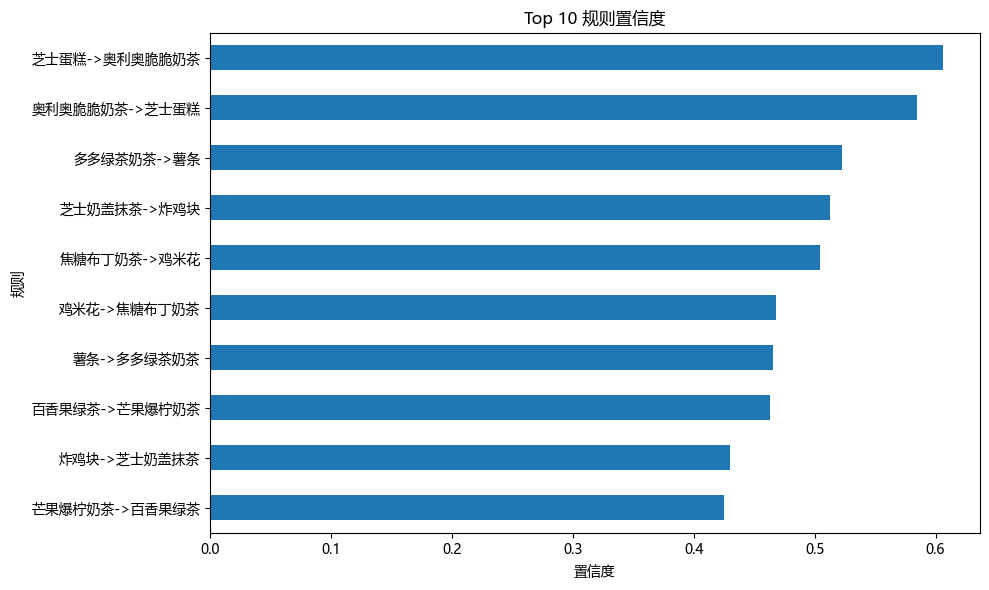

In [4]:
# 目的：复现 Gold Match 的核心规则表（Top 10）
rules, frequent_1, frequent_2 = get_rules_summary()
rule_df = pd.DataFrame(rules)

if not rule_df.empty:
    top_rules = rule_df.sort_values(["confidence", "lift"], ascending=False).head(10)
    display(top_rules[["lhs", "rhs", "support", "confidence", "lift", "level"]])

    ax = top_rules.set_index(top_rules["lhs"] + "->" + top_rules["rhs"])["confidence"].plot(
        kind="barh", figsize=(10, 6)
    )
    ax.set_title("Top 10 规则置信度")
    ax.set_xlabel("置信度")
    ax.set_ylabel("规则")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("当前规则为空，请检查样本窗口或最小支持度参数。")

### 5.3.3 用户分群可视化（Segmentation）

- 插入截图：用户分群页面（可命名为图5-10）
- 说明重点：将用户按消费频次划分为高/中/低活跃群体。

segment
高活跃    29
中活跃    29
低活跃    29
Name: count, dtype: int64

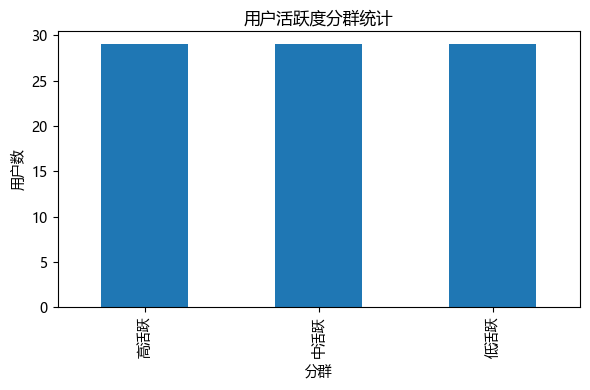

In [5]:
# 目的：基于用户订单次数进行简易分群（高/中/低活跃）
try:
    sql = """
    SELECT user_id, COUNT(*) AS order_cnt
    FROM orders
    WHERE status IN ('paid', 'picked', 'done')
    GROUP BY user_id
    """
    seg_df = fetch_df(sql)

    seg_df["order_cnt"] = pd.to_numeric(seg_df["order_cnt"], errors="coerce")
    seg_df = seg_df.dropna(subset=["order_cnt"])

    if len(seg_df) >= 3 and seg_df["order_cnt"].nunique() >= 2:
        seg_df["segment"] = pd.qcut(
            seg_df["order_cnt"],
            q=3,
            labels=["低活跃", "中活跃", "高活跃"],
            duplicates="drop",
        )
        seg_count = seg_df["segment"].value_counts().reindex(["高活跃", "中活跃", "低活跃"], fill_value=0)
        display(seg_count)

        ax = seg_count.plot(kind="bar", figsize=(6, 4))
        ax.set_title("用户活跃度分群统计")
        ax.set_xlabel("分群")
        ax.set_ylabel("用户数")
        plt.tight_layout()
        plt.show()
    else:
        print("用户样本过少或订单次数无差异，无法进行分位分群。")
except Exception as e:
    print("用户分群图生成失败，请检查字段名或数据库连接。")
    print("错误信息:", e)

### 5.3.4 实时销售可视化（Realtime Sales）

- 插入截图：实时销售页面（可命名为图5-11）
- 说明重点：按小时/日期观察订单量或销售额波动。

,hour_no,order_cnt,sales_amt
0,0,1,61.0
1,9,26925,1500796.0
2,10,34422,1919821.0
3,11,34338,1922009.0
4,12,34368,1918654.0
5,13,34166,1895657.0
6,14,34476,1921377.0
7,15,34224,1900285.0
8,16,34174,1899341.0
9,17,34299,1913659.0


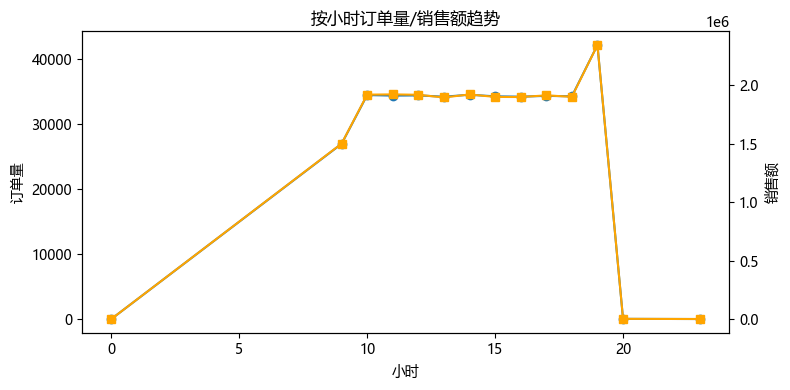

In [6]:
# 目的：输出按小时订单量（以及可用时的销售额）
try:
    amount_candidates = ["paid_amount", "payable_amount", "total_amount", "discount_amount"]
    amount_col = next((c for c in amount_candidates if c in orders_cols), None)

    if amount_col:
        sql = f"""
        SELECT HOUR(paid_at) AS hour_no,
               COUNT(*) AS order_cnt,
               SUM({amount_col}) AS sales_amt
        FROM orders
        WHERE status IN ('paid', 'picked', 'done')
          AND paid_at IS NOT NULL
        GROUP BY HOUR(paid_at)
        ORDER BY hour_no
        """
        rt_df = fetch_df(sql)
        rt_df["hour_no"] = pd.to_numeric(rt_df["hour_no"], errors="coerce")
        rt_df["order_cnt"] = pd.to_numeric(rt_df["order_cnt"], errors="coerce")
        rt_df["sales_amt"] = pd.to_numeric(rt_df["sales_amt"], errors="coerce")
        rt_df = rt_df.dropna(subset=["hour_no", "order_cnt", "sales_amt"]).sort_values("hour_no")
        display(rt_df)

        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax1.plot(rt_df["hour_no"], rt_df["order_cnt"], marker="o", label="订单量")
        ax1.set_xlabel("小时")
        ax1.set_ylabel("订单量")
        ax1.set_title("按小时订单量/销售额趋势")

        ax2 = ax1.twinx()
        ax2.plot(rt_df["hour_no"], rt_df["sales_amt"], marker="s", color="orange", label="销售额")
        ax2.set_ylabel("销售额")

        plt.tight_layout()
        plt.show()
    else:
        sql = """
        SELECT HOUR(paid_at) AS hour_no, COUNT(*) AS order_cnt
        FROM orders
        WHERE status IN ('paid', 'picked', 'done')
          AND paid_at IS NOT NULL
        GROUP BY HOUR(paid_at)
        ORDER BY hour_no
        """
        rt_df = fetch_df(sql)
        rt_df["hour_no"] = pd.to_numeric(rt_df["hour_no"], errors="coerce")
        rt_df["order_cnt"] = pd.to_numeric(rt_df["order_cnt"], errors="coerce")
        rt_df = rt_df.dropna(subset=["hour_no", "order_cnt"]).sort_values("hour_no")
        display(rt_df)

        ax = rt_df.plot(x="hour_no", y="order_cnt", marker="o", figsize=(8, 4))
        ax.set_title("按小时订单量趋势")
        ax.set_xlabel("小时")
        ax.set_ylabel("订单量")
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("实时销售图生成失败，请检查字段名或数据库连接。")
    print("错误信息:", e)

## 小节结论模板（答辩可直接口述）

- Customer Profile：该图展示了用户消费活跃度分布，可用于识别高价值客群。
- Gold Match：该图展示了高置信度与高提升度组合，可用于套餐设计与搭配推荐。
- Segmentation：该图展示了高/中/低活跃用户结构，可用于差异化营销策略。
- Realtime Sales：该图展示了销售时段波动，可用于高峰排班与库存准备。